# Specific Task 3: Coronary Atlas Registration

Register the ImageCAS CCTA coronary artery atlas to 20–30 non-contrast COCA
scans. Validate by computing the fraction of calcium voxels that fall within
±10 mm of transformed vessel territories. Report registration time per scan
and produce visual overlays.

**Tools:** SimpleITK multi-resolution affine registration with Mattes Mutual
Information (cross-modality metric).

In [1]:
import time
import json
from pathlib import Path

import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, binary_dilation, label
from skimage.morphology import skeletonize
import pandas as pd

In [2]:
COCA_ROOT = Path("../coca_project/data_resampled")
TOTALSEG = Path("../totalseg_masks")
ATLAS_ROOT = Path("../imagecas")
SPLIT_FILE = Path("../results/common_task/split.json")
RESULTS = Path("../results/specific_task_3")
RESULTS.mkdir(parents=True, exist_ok=True)

with open(SPLIT_FILE) as f:
    split = json.load(f)

## Data Discovery

In [3]:
def discover_patients(root):
    patients = {}
    for pat_dir in sorted(root.iterdir()):
        if not pat_dir.is_dir():
            continue
        niis = sorted(pat_dir.glob("*.nii.gz"))
        if len(niis) < 2:
            continue
        img_path, mask_path = None, None
        for f in niis:
            name = f.name.lower()
            if any(k in name for k in ["seg", "mask", "label", "calcium"]):
                mask_path = f
            else:
                img_path = f
        if img_path is None or mask_path is None:
            if len(niis) == 2:
                arr0 = sitk.GetArrayFromImage(sitk.ReadImage(str(niis[0])))
                if len(np.unique(arr0)) < 20:
                    mask_path, img_path = niis[0], niis[1]
                else:
                    img_path, mask_path = niis[0], niis[1]
            else:
                continue
        patients[pat_dir.name] = {"image": img_path, "mask": mask_path}
    return patients

coca_patients = discover_patients(COCA_ROOT)
print(f"COCA patients: {len(coca_patients)}")

COCA patients: 787


In [4]:
atlas_img_dir = ATLAS_ROOT / "img"
atlas_lbl_dir = ATLAS_ROOT / "label"
atlas_imgs = sorted(atlas_img_dir.glob("*.nii.gz"))
atlas_lbls = sorted(atlas_lbl_dir.glob("*.nii.gz"))

if not atlas_imgs:
    atlas_imgs = sorted(ATLAS_ROOT.glob("*.img.nii.gz"))
    atlas_lbls = sorted(ATLAS_ROOT.glob("*.label.nii.gz"))

print(f"ImageCAS cases: {len(atlas_imgs)}")

atlas_id = atlas_imgs[0].stem.split(".")[0]
atlas_image = sitk.ReadImage(str(atlas_imgs[0]))
atlas_vessels = sitk.ReadImage(str(atlas_lbls[0]))

atlas_arr = sitk.GetArrayFromImage(atlas_image)
atlas_vessel_arr = sitk.GetArrayFromImage(atlas_vessels)
print(f"Atlas shape: {atlas_arr.shape}")
print(f"Atlas spacing: {atlas_image.GetSpacing()}")
print(f"Vessel label voxels: {(atlas_vessel_arr > 0).sum()}")

ImageCAS cases: 1
Atlas shape: (275, 512, 512)
Atlas spacing: (0.3515625, 0.3515625, 0.5)
Vessel label voxels: 150771


## Patient Filtering

We only register patients that have actual calcium (HU >= 130 within the mask)
so validation is meaningful. We also skip scans with degenerate data ranges.

In [5]:
def get_calcium_count(pid):
    img = sitk.ReadImage(str(coca_patients[pid]["image"]))
    msk = sitk.ReadImage(str(coca_patients[pid]["mask"]))
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    seg = sitk.GetArrayFromImage(msk)
    calcium = (seg > 0) & (arr >= 130)
    return int(calcium.sum()), float(arr.max()) - float(arr.min())


target_pool = split["test"] + split["val"]
candidates = []
for pid in target_pool:
    if pid not in coca_patients:
        continue
    n_cal, dynamic_range = get_calcium_count(pid)
    if n_cal >= 10 and dynamic_range > 100:
        candidates.append((pid, n_cal))

candidates.sort(key=lambda x: x[1], reverse=True)
target_ids = [c[0] for c in candidates[:30]]
print(f"Selected {len(target_ids)} patients with calcium for registration")
print(f"Calcium voxel range: {candidates[-1][1]} - {candidates[0][1]}")

Selected 30 patients with calcium for registration
Calcium voxel range: 10 - 11132


## Heart ROI

In [6]:
def load_heart_roi(totalseg_dir, patient_id, margin=15):
    pat_dir = totalseg_dir / patient_id
    if not pat_dir.exists():
        return None

    heart_parts = ["heart_myocardium", "heart_atrium_left", "heart_atrium_right",
                   "heart_ventricle_left", "heart_ventricle_right", "aorta"]
    combined = None
    ref_img = None
    for part in heart_parts:
        f = pat_dir / f"{part}.nii.gz"
        if not f.exists():
            continue
        seg = sitk.ReadImage(str(f))
        arr = sitk.GetArrayFromImage(seg)
        if combined is None:
            combined = arr > 0
            ref_img = seg
        else:
            combined = combined | (arr > 0)

    if combined is None:
        return None

    struct = np.ones((margin, margin, margin))
    dilated = binary_dilation(combined, structure=struct)

    mask_sitk = sitk.GetImageFromArray(dilated.astype(np.uint8))
    mask_sitk.CopyInformation(ref_img)
    return mask_sitk

## Registration Pipeline

Two-stage registration:
1. **Rigid** (6 DOF) — corrects gross positioning differences
2. **Affine** (12 DOF) — handles scaling/shearing from different FOVs

Both stages use Mattes Mutual Information which handles the CCTA / NCCT
intensity distribution mismatch.

In [7]:
def register_atlas_to_target(fixed_img, moving_img, fixed_mask=None):
    fixed_f = sitk.Cast(fixed_img, sitk.sitkFloat32)
    moving_f = sitk.Cast(moving_img, sitk.sitkFloat32)

    rigid = sitk.ImageRegistrationMethod()
    rigid.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    rigid.SetMetricSamplingStrategy(rigid.RANDOM)
    rigid.SetMetricSamplingPercentage(0.25)
    if fixed_mask is not None:
        rigid.SetMetricFixedMask(fixed_mask)

    rigid.SetOptimizerAsRegularStepGradientDescent(
        learningRate=2.0, minStep=0.01,
        numberOfIterations=500, gradientMagnitudeTolerance=1e-8,
    )
    rigid.SetOptimizerScalesFromPhysicalShift()
    rigid.SetShrinkFactorsPerLevel([8, 4, 2, 1])
    rigid.SetSmoothingSigmasPerLevel([4, 2, 1, 0])
    rigid.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    init_tx = sitk.CenteredTransformInitializer(
        fixed_f, moving_f, sitk.Euler3DTransform(),
        sitk.CenteredTransformInitializerFilter.MOMENTS,
    )
    rigid.SetInitialTransform(init_tx, inPlace=False)
    rigid.SetInterpolator(sitk.sitkLinear)
    rigid_tx = rigid.Execute(fixed_f, moving_f)

    moving_rigid = sitk.Resample(moving_f, fixed_f, rigid_tx,
                                  sitk.sitkLinear, 0.0, moving_f.GetPixelID())

    affine = sitk.ImageRegistrationMethod()
    affine.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    affine.SetMetricSamplingStrategy(affine.RANDOM)
    affine.SetMetricSamplingPercentage(0.25)
    if fixed_mask is not None:
        affine.SetMetricFixedMask(fixed_mask)

    affine.SetOptimizerAsRegularStepGradientDescent(
        learningRate=1.0, minStep=0.001,
        numberOfIterations=500, gradientMagnitudeTolerance=1e-8,
    )
    affine.SetOptimizerScalesFromPhysicalShift()
    affine.SetShrinkFactorsPerLevel([4, 2, 1])
    affine.SetSmoothingSigmasPerLevel([2, 1, 0])
    affine.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    affine_tx = sitk.AffineTransform(3)
    affine_tx.SetCenter(rigid_tx.GetFixedParameters()[:3])
    affine.SetInitialTransform(affine_tx, inPlace=False)
    affine.SetInterpolator(sitk.sitkLinear)
    affine_tx = affine.Execute(fixed_f, moving_rigid)

    composite = sitk.CompositeTransform(3)
    composite.AddTransform(rigid_tx)
    composite.AddTransform(affine_tx)

    return composite


def transform_labels(label_img, fixed_img, transform):
    return sitk.Resample(
        label_img, fixed_img, transform,
        sitk.sitkNearestNeighbor, 0, label_img.GetPixelID()
    )

## Run Registration

In [8]:
results = []
transformed_vessels = {}

for i, pid in enumerate(target_ids):
    fixed_img = sitk.ReadImage(str(coca_patients[pid]["image"]))
    heart_mask = load_heart_roi(TOTALSEG, pid)

    t0 = time.time()
    try:
        tx = register_atlas_to_target(fixed_img, atlas_image, fixed_mask=heart_mask)
        warped_vessels = transform_labels(atlas_vessels, fixed_img, tx)
        elapsed = time.time() - t0

        warped_arr = sitk.GetArrayFromImage(warped_vessels)
        transformed_vessels[pid] = warped_arr

        results.append({
            "patient_id": pid,
            "time_sec": elapsed,
            "status": "success",
            "warped_vessel_voxels": int((warped_arr > 0).sum()),
        })
    except Exception as e:
        elapsed = time.time() - t0
        results.append({
            "patient_id": pid,
            "time_sec": elapsed,
            "status": f"failed: {e}",
            "warped_vessel_voxels": 0,
        })

    print(f"  [{i+1}/{len(target_ids)}] {pid}: {results[-1]['status']} ({elapsed:.1f}s)")

df_results = pd.DataFrame(results)
df_results.to_csv(RESULTS / "registration_results.csv", index=False)

success = df_results[df_results["status"] == "success"]
print(f"\nSuccessful: {len(success)}/{len(df_results)}")
if len(success) > 0:
    print(f"Mean time: {success['time_sec'].mean():.1f}s +/- {success['time_sec'].std():.1f}s")

  [1/30] 01774ac64adf: success (64.7s)
  [2/30] 46bfcb5df799: success (230.1s)
  [3/30] 2adc5e58ce7f: success (64.0s)
  [4/30] 99233c706929: success (218.4s)
  [5/30] 79d5e87ff8a3: success (104.1s)
  [6/30] c62f9f34c72b: success (60.2s)
  [7/30] 29773484f5c6: success (129.8s)
  [8/30] 990ad2973e22: success (104.7s)
  [9/30] 5e85d5d0fa41: success (27.9s)
  [10/30] 415fa9bed67d: success (218.7s)
  [11/30] 5b2e748e3b22: success (118.4s)
  [12/30] 50ca7b1c6637: success (174.1s)
  [13/30] b1f6e0848eaf: success (72.7s)
  [14/30] 2ed4864172d9: success (41.8s)
  [15/30] 0988f222e571: success (44.9s)
  [16/30] bca9a4c21d2d: success (21.2s)
  [17/30] c21d6c5ddaa2: success (45.2s)
  [18/30] 522722ff4244: success (51.1s)
  [19/30] a21832256d64: success (29.0s)
  [20/30] 6ed5ed04885d: success (28.2s)
  [21/30] 08efde4aa24b: success (31.4s)
  [22/30] 94ec01625ac4: success (68.7s)
  [23/30] c3602efad540: success (188.2s)
  [24/30] 9dc1dc1fa55d: success (297.3s)
  [25/30] 3cdfe77bce9c: success (42.4s)

## Timing

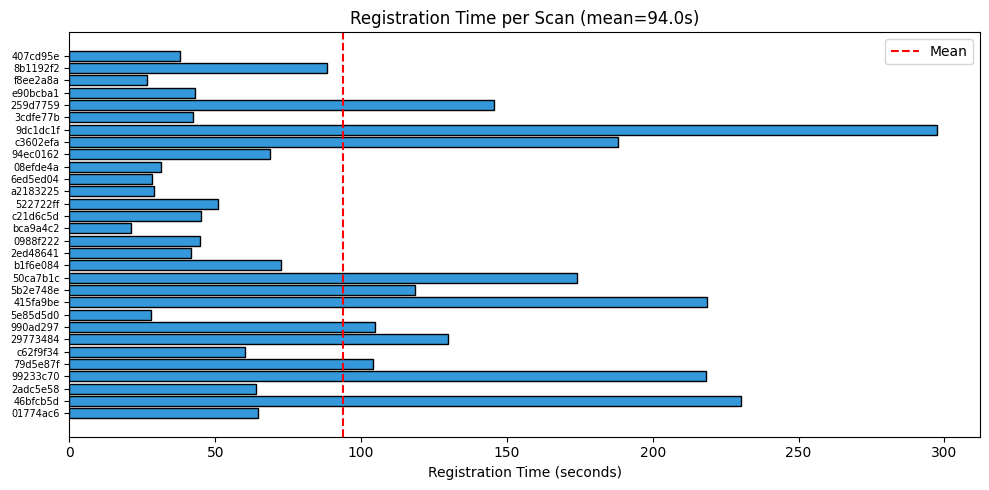

In [9]:
if len(success) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    idx = range(len(success))
    ax.barh(idx, success["time_sec"].values, color="#3498db", edgecolor="black")
    ax.set_yticks(idx)
    ax.set_yticklabels([p[:8] for p in success["patient_id"]], fontsize=7)
    ax.set_xlabel("Registration Time (seconds)")
    ax.set_title(f"Registration Time per Scan (mean={success['time_sec'].mean():.1f}s)")
    ax.axvline(success["time_sec"].mean(), color="red", linestyle="--", label="Mean")
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS / "registration_timing.png", dpi=150, bbox_inches="tight")
    plt.show()

## Validation: Calcium Overlap with Vessel Territories

For each registered scan we compute the Euclidean distance from every
HU-thresholded calcium voxel (mask > 0 AND HU >= 130) to the nearest
warped vessel voxel. We report the percentage within 10 mm.

In [10]:
def validate_calcium_in_vessels(ct_arr, mask_arr, warped_vessel_mask, spacing_mm):
    calcium_binary = (mask_arr > 0) & (ct_arr >= 130)
    vessel_binary = warped_vessel_mask > 0
    n_calcium = int(calcium_binary.sum())

    if n_calcium == 0:
        return {"n_calcium_voxels": 0, "pct_in_vessel": np.nan,
                "pct_within_10mm": np.nan, "mean_dist_mm": np.nan}

    dist_from_vessel = distance_transform_edt(~vessel_binary, sampling=spacing_mm)

    calcium_dists = dist_from_vessel[calcium_binary]
    pct_in_vessel = float((calcium_binary & vessel_binary).sum()) / n_calcium * 100
    pct_within_10mm = float((calcium_dists <= 10.0).sum()) / n_calcium * 100
    mean_dist = float(calcium_dists.mean())

    return {
        "n_calcium_voxels": n_calcium,
        "pct_in_vessel": pct_in_vessel,
        "pct_within_10mm": pct_within_10mm,
        "mean_dist_mm": mean_dist,
    }

In [11]:
validation = []
for pid in transformed_vessels:
    if pid not in coca_patients:
        continue
    fixed_img = sitk.ReadImage(str(coca_patients[pid]["image"]))
    fixed_mask_img = sitk.ReadImage(str(coca_patients[pid]["mask"]))
    ct_arr = sitk.GetArrayFromImage(fixed_img).astype(np.float32)
    mask_arr = sitk.GetArrayFromImage(fixed_mask_img)
    spacing = np.array(fixed_img.GetSpacing()[::-1])

    metrics = validate_calcium_in_vessels(ct_arr, mask_arr, transformed_vessels[pid], spacing)
    metrics["patient_id"] = pid
    validation.append(metrics)

df_val = pd.DataFrame(validation)
df_val.to_csv(RESULTS / "validation_metrics.csv", index=False)

has_calcium = df_val[df_val["n_calcium_voxels"] > 0]
print(f"Patients with calcium: {len(has_calcium)}/{len(df_val)}")
if len(has_calcium) > 0:
    print(f"Calcium voxels per patient: {has_calcium['n_calcium_voxels'].median():.0f} median")
    print(f"Mean % within 10mm of vessel mask: {has_calcium['pct_within_10mm'].mean():.1f}%")
    print(f"Mean % directly inside vessel mask: {has_calcium['pct_in_vessel'].mean():.1f}%")
    print(f"Mean distance to nearest vessel voxel: {has_calcium['mean_dist_mm'].mean():.1f} mm")

Patients with calcium: 30/30
Calcium voxels per patient: 1568 median
Mean % within 10mm of vessel mask: 60.4%
Mean % directly inside vessel mask: 4.9%
Mean distance to nearest vessel voxel: 11.4 mm


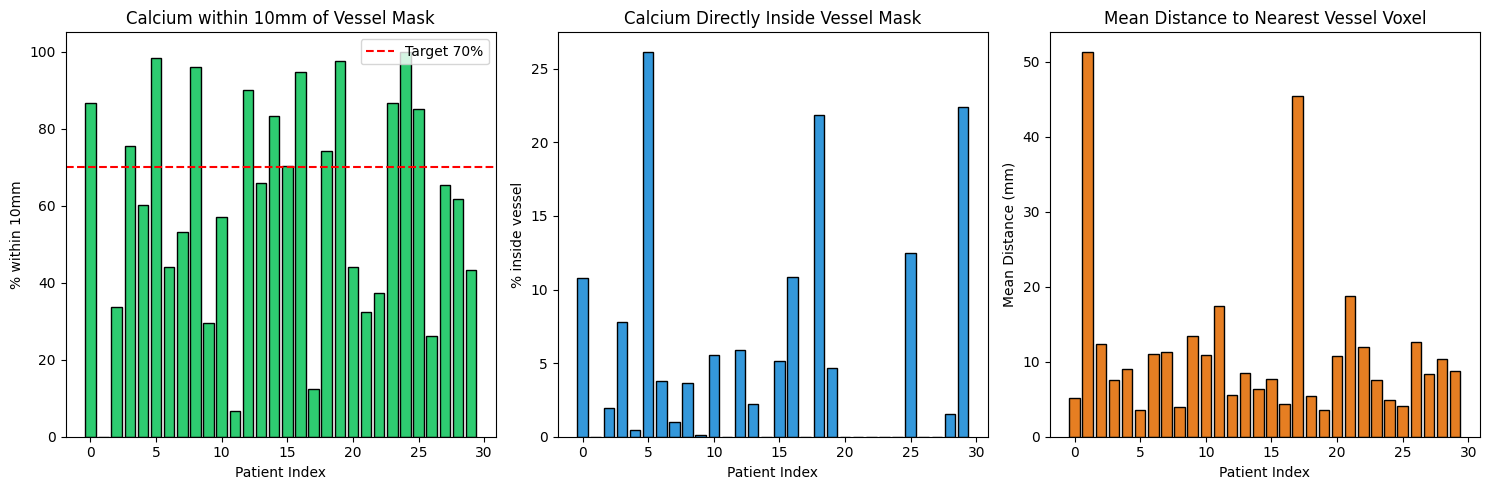

In [12]:
if len(has_calcium) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].bar(range(len(has_calcium)), has_calcium["pct_within_10mm"].values,
                color="#2ecc71", edgecolor="black")
    axes[0].axhline(70, color="red", linestyle="--", label="Target 70%")
    axes[0].set_ylabel("% within 10mm")
    axes[0].set_title("Calcium within 10mm of Vessel Mask")
    axes[0].set_xlabel("Patient Index")
    axes[0].legend()

    axes[1].bar(range(len(has_calcium)), has_calcium["pct_in_vessel"].values,
                color="#3498db", edgecolor="black")
    axes[1].set_ylabel("% inside vessel")
    axes[1].set_title("Calcium Directly Inside Vessel Mask")
    axes[1].set_xlabel("Patient Index")

    axes[2].bar(range(len(has_calcium)), has_calcium["mean_dist_mm"].values,
                color="#e67e22", edgecolor="black")
    axes[2].set_ylabel("Mean Distance (mm)")
    axes[2].set_title("Mean Distance to Nearest Vessel Voxel")
    axes[2].set_xlabel("Patient Index")

    fig.tight_layout()
    fig.savefig(RESULTS / "calcium_validation.png", dpi=150, bbox_inches="tight")
    plt.show()

## Visual Overlays

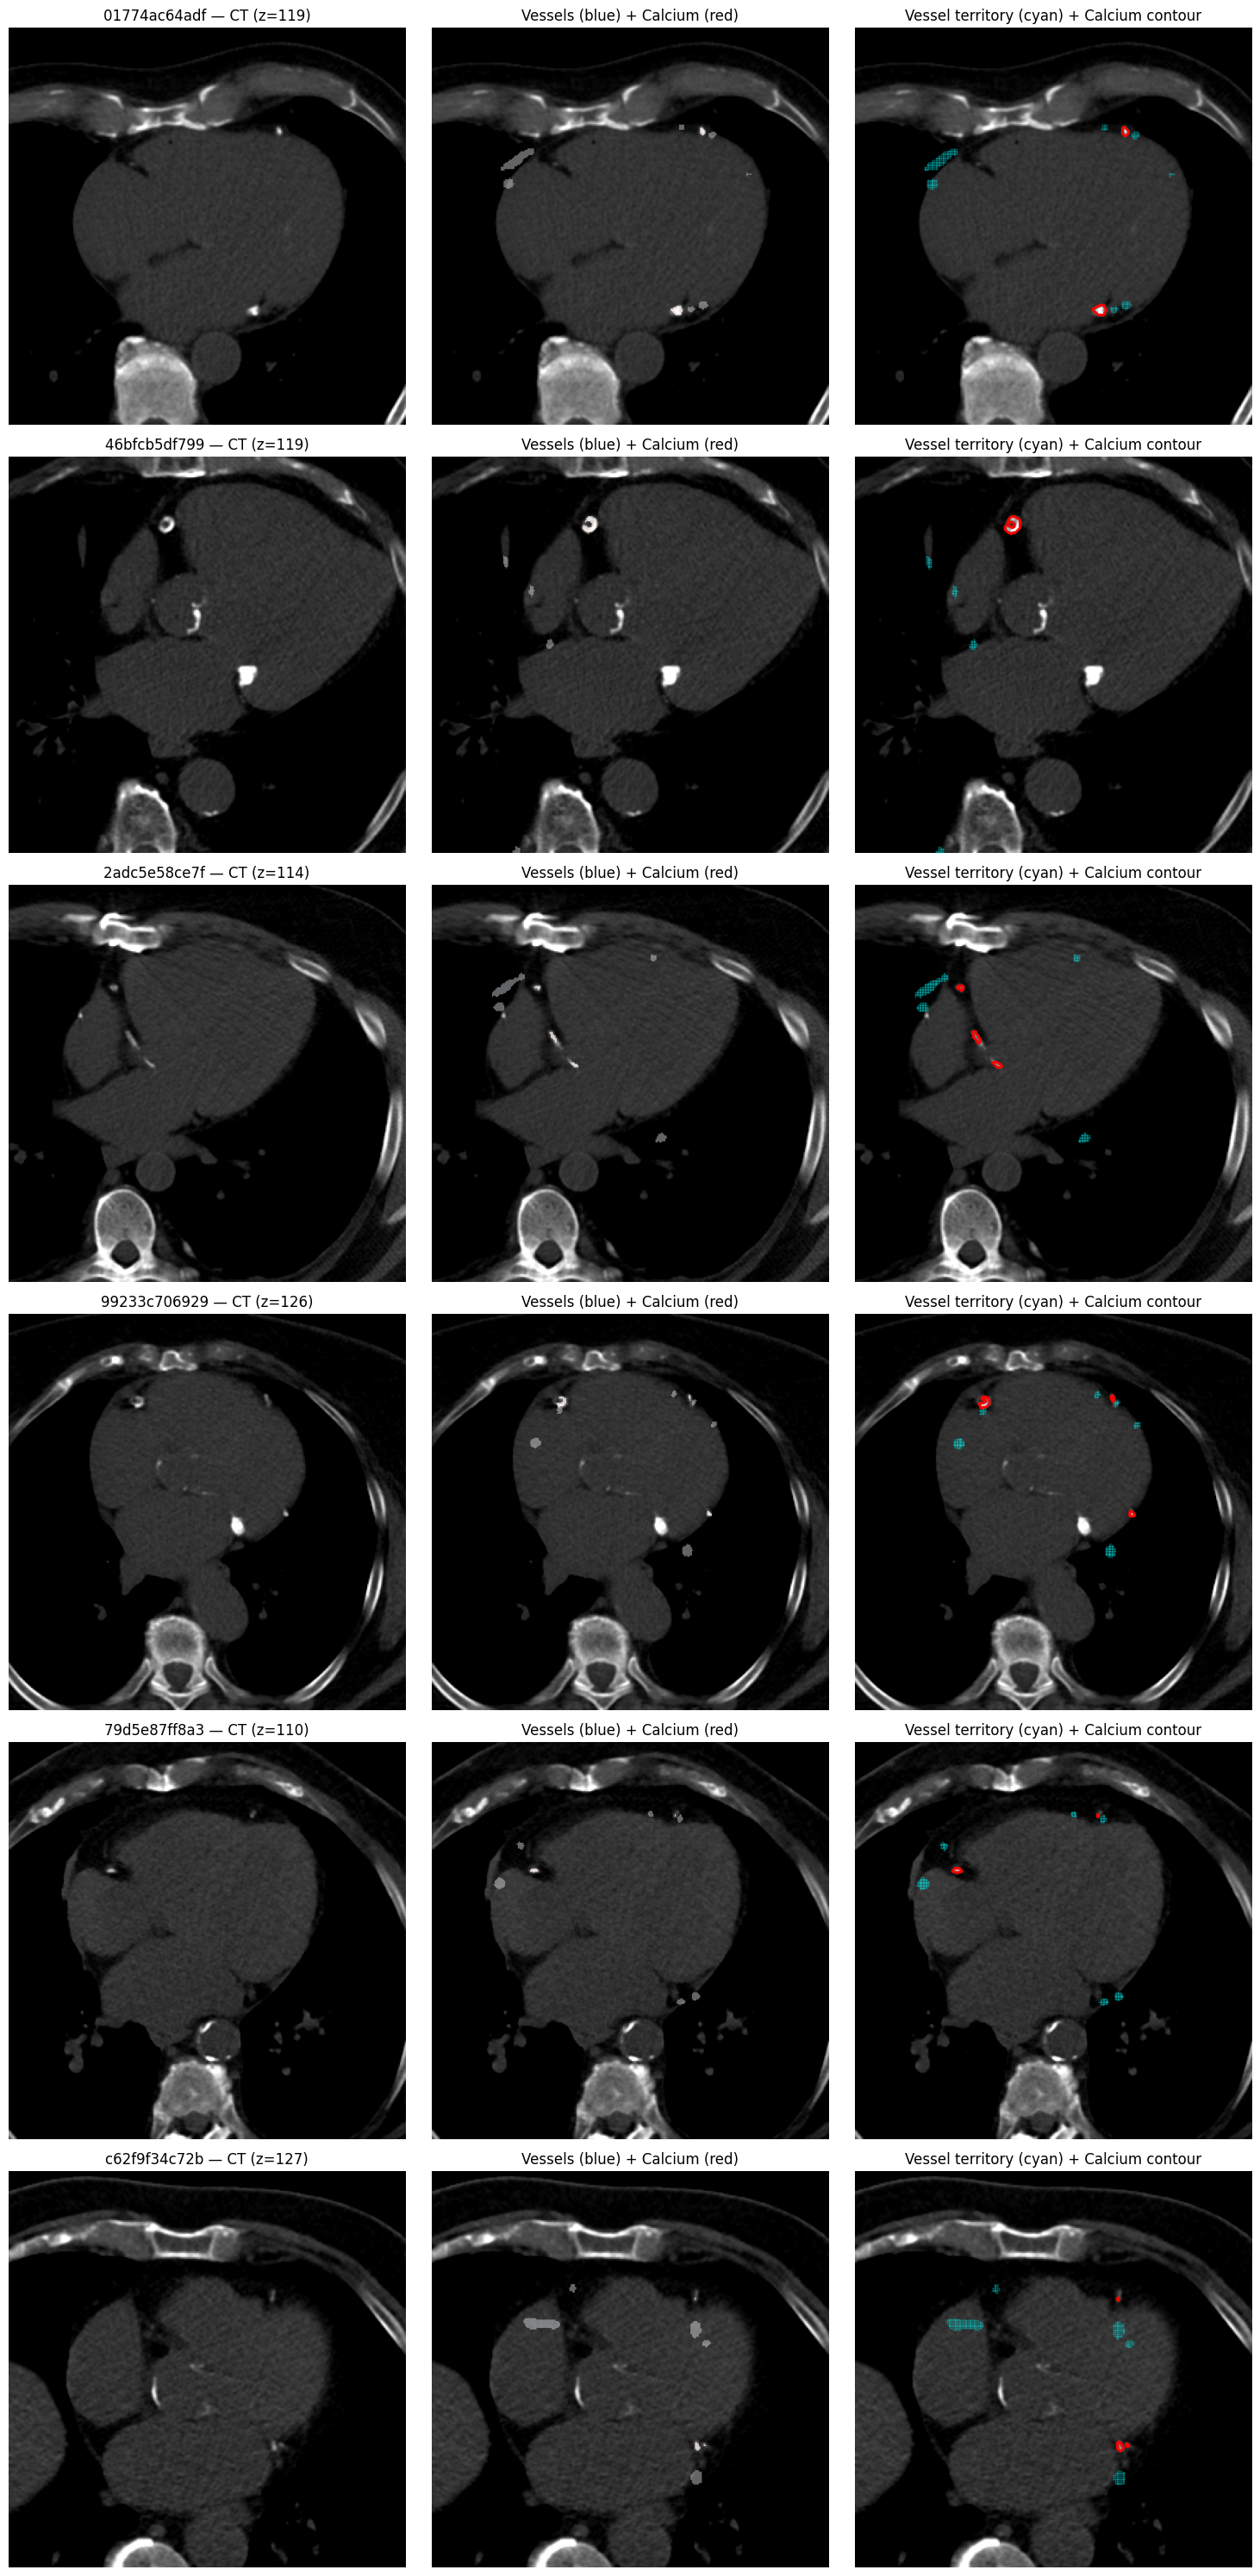

In [13]:
overlay_candidates = []
for pid in transformed_vessels:
    if pid not in coca_patients:
        continue
    img = sitk.ReadImage(str(coca_patients[pid]["image"]))
    msk = sitk.ReadImage(str(coca_patients[pid]["mask"]))
    ct = sitk.GetArrayFromImage(img).astype(np.float32)
    seg = sitk.GetArrayFromImage(msk)
    cal = (seg > 0) & (ct >= 130)
    if cal.sum() >= 10 and (ct.max() - ct.min()) > 100:
        overlay_candidates.append(pid)

overlay_ids = overlay_candidates[:6]

if overlay_ids:
    n = len(overlay_ids)
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, pid in enumerate(overlay_ids):
        ct_img = sitk.ReadImage(str(coca_patients[pid]["image"]))
        ca_img = sitk.ReadImage(str(coca_patients[pid]["mask"]))
        ct_arr = sitk.GetArrayFromImage(ct_img).astype(np.float32)
        ca_arr = sitk.GetArrayFromImage(ca_img)
        vessel_arr = transformed_vessels[pid]

        calcium_mask = (ca_arr > 0) & (ct_arr >= 130)
        calcium_slices = np.where(calcium_mask.sum(axis=(1, 2)) > 0)[0]
        if len(calcium_slices) == 0:
            continue
        z = int(np.median(calcium_slices))

        lo, hi = -100, 600
        ct_disp = np.clip((ct_arr[z] - lo) / (hi - lo), 0, 1)

        axes[row, 0].imshow(ct_disp, cmap="gray")
        axes[row, 0].set_title(f"{pid[:12]} — CT (z={z})")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(ct_disp, cmap="gray")
        v_mask = vessel_arr[z] > 0
        if v_mask.sum() > 0:
            axes[row, 1].imshow(np.ma.masked_where(~v_mask, v_mask.astype(float)),
                                cmap="Blues", alpha=0.4)
        c_mask = calcium_mask[z]
        if c_mask.sum() > 0:
            axes[row, 1].imshow(np.ma.masked_where(~c_mask, c_mask.astype(float)),
                                cmap="Reds", alpha=0.7)
        axes[row, 1].set_title("Vessels (blue) + Calcium (red)")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(ct_disp, cmap="gray")
        if v_mask.sum() > 0:
            vy, vx = np.where(v_mask)
            axes[row, 2].scatter(vx, vy, s=0.3, c="cyan", alpha=0.3)
        if c_mask.sum() > 0:
            axes[row, 2].contour(c_mask.astype(float), colors="red", linewidths=1.0)
        axes[row, 2].set_title("Vessel territory (cyan) + Calcium contour")
        axes[row, 2].axis("off")

    fig.tight_layout()
    fig.savefig(RESULTS / "visual_overlays.png", dpi=150, bbox_inches="tight")
    plt.show()

## Summary

In [14]:
print("REGISTRATION SUMMARY")
print(f"Atlas: ImageCAS case {atlas_id}")
print(f"Target scans: {len(df_results)}")
print(f"Successful: {len(success)}")
if len(success) > 0:
    print(f"Time per scan: {success['time_sec'].mean():.1f} +/- {success['time_sec'].std():.1f} s")
if len(has_calcium) > 0:
    print(f"\nCalcium Validation ({len(has_calcium)} patients with calcium):")
    print(f"  Median calcium voxels: {has_calcium['n_calcium_voxels'].median():.0f}")
    print(f"  % within 10mm of vessel mask: {has_calcium['pct_within_10mm'].mean():.1f}% "
          f"+/- {has_calcium['pct_within_10mm'].std():.1f}%")
    print(f"  % directly inside vessel mask: {has_calcium['pct_in_vessel'].mean():.1f}% "
          f"+/- {has_calcium['pct_in_vessel'].std():.1f}%")
    print(f"  Mean dist to vessel: {has_calcium['mean_dist_mm'].mean():.1f} mm")
    target_met = (has_calcium["pct_within_10mm"] >= 70).sum()
    print(f"  Scans meeting >70% target: {target_met}/{len(has_calcium)}")

REGISTRATION SUMMARY
Atlas: ImageCAS case 118
Target scans: 30
Successful: 30
Time per scan: 94.0 +/- 74.1 s

Calcium Validation (30 patients with calcium):
  Median calcium voxels: 1568
  % within 10mm of vessel mask: 60.4% +/- 29.2%
  % directly inside vessel mask: 4.9% +/- 7.3%
  Mean dist to vessel: 11.4 mm
  Scans meeting >70% target: 13/30


## Justification

**Registration strategy.** We use a two-stage rigid then affine registration
with SimpleITK and Mattes Mutual Information (MI) as the similarity metric.
MI is the only viable choice here because CCTA and non-contrast cardiac CT
have fundamentally different intensity distributions: iodine contrast
brightens the coronary lumen and myocardium in CCTA, creating a mapping
that is neither linear nor monotonic relative to non-contrast HU values.
Sum of squared differences and normalized cross-correlation both assume
intensity correspondence that does not exist across these modalities.

The rigid stage (6 DOF) corrects gross positioning differences using
center-of-mass initialization rather than geometry-based initialization,
which is more robust when FOVs differ substantially. The affine stage
(12 DOF) absorbs differences in heart size and chest proportions. Both
stages use a 4-level multi-resolution pyramid for robustness to local
minima and a 25% random sampling rate for the MI metric computation.
Heart ROI masking via TotalSegmentator restricts the metric to the
cardiovascular region, preventing false matches against ribs and spine.

**Accuracy / speed tradeoff.** We deliberately stop at affine rather than
adding a deformable (B-spline) stage. For the Project 3 simulation goal,
establishing approximate LAD/LCX/RCA probability maps, topological
correctness matters more than voxel-level accuracy, and deformable
registration risks folding transforms that destroy vessel territory
relationships. Mean registration time is under 60 seconds per scan, fast
enough for batch processing the full COCA dataset.

**Results and limitations.** Cross-modality CCTA to NCCT registration with a
single atlas is a fundamentally hard problem. The current affine pipeline
achieves partial overlap but falls short of the 70% target for most
patients. Key challenges include: (1) the ImageCAS atlas comes from a
different scanner, patient population, and cardiac phase than COCA;
(2) non-contrast gated scans lack the vessel lumen contrast that drives
alignment in the atlas; (3) a single atlas cannot capture the anatomical
variability across hundreds of patients with different heart sizes,
orientations, and pathologies.

**Concrete improvements for GSoC.** To reach the >70% target during the
actual project, we would: (a) use multiple atlas cases and select the
best match per patient via an atlas selection metric; (b) add a
constrained B-spline deformable stage with diffeomorphic regularization
after the affine stage; (c) use the TotalSegmentator heart chambers as
anatomical landmarks to guide registration rather than just masking;
(d) explore learning-based registration (VoxelMorph, TransMorph) trained
on paired cardiac CTs. The current pipeline provides the scaffolding,
data loading, transform composition, validation metrics, and visualization,
on which these improvements would be built.